In [2]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph ,END ,START
from langchain_core.prompts import ChatPromptTemplate
from typing import TypedDict,Dict,Any
from pydantic import BaseModel,Field
from langchain_groq import ChatGroq



In [3]:
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")


In [4]:
class State(TypedDict):
    input_text:str
    extract_entaties:list[Dict[str,any]]
    cypher_query:str
    db_state:str




In [ ]:
from ast import List


# ==========================================
# 1. DEFINE SHARED PIPELINE STATE
# ==========================================
class PipelineState(TypedDict):
    input_text: str
    extracted_entities: List[Dict[str, Any]]
    cypher_query: str
    db_status: str

# Pydantic Schema for Structured Output in Agent 1
class EntityRelation(BaseModel):
    source_entity: str = Field(description="Name of the source node")
    source_label: str = Field(description="Type/Label of source node e.g. Person, Company")
    relationship: str = Field(description="Relationship name e.g. WORKS_AT, LOCATED_IN")
    target_entity: str = Field(description="Name of the target node")
    target_label: str = Field(description="Type/Label of target node e.g. Company, City")

class KnowledgeGraphExtraction(BaseModel):
    triples: List[EntityRelation] = Field(description="List of extracted graph triples")





In [4]:
# ==========================================
# 2. DEFINE AGENT NODES
# ==========================================

def entity_mapper_agent(state: PipelineState) -> dict:
    """Agent A: Extracts entities and relationships from raw unstructured text."""
    print("\n--- [AGENT 1] Extracting Entities & Relationships ---")
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Extract all key entities, their labels, and their relationships from the text."),
        ("user", "{text}")
    ])
    
    structured_llm = llm.with_structured_output(KnowledgeGraphExtraction)
    chain = prompt | structured_llm
    
    result = chain.invoke({"text": state["input_text"]})
    triples = [t.model_dump() for t in result.triples]
    
    print(f"Extracted {len(triples)} relationships.")
    return {"extracted_entities": triples}

def cypher_translator_agent(state: PipelineState) -> dict:
    """Agent B: Converts extracted triples into Neo4j Cypher queries."""
    print("\n--- [AGENT 2] Translating Entities to Cypher Query ---")
    
    triples = state["extracted_entities"]
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a Cypher query generator. Convert the following extracted relationships into a single, syntactically correct Neo4j MERGE Cypher query."),
        ("user", "Relationships: {triples}")
    ])
    
    chain = prompt | llm
    response = chain.invoke({"triples": str(triples)})
    cypher_query = response.content.strip()
    
    print(f"Generated Cypher Query:\n{cypher_query}")
    return {"cypher_query": cypher_query}

def db_executor_agent(state: PipelineState) -> dict:
    """Agent C: Simulates executing the Cypher query against the Graph DB."""
    print("\n--- [AGENT 3] Executing Query on Database ---")
    
    query = state["cypher_query"]
    
    status = f"SUCCESS: Graph updated successfully using generated query."
    print(status)
    
    return {"db_status": status}



In [5]:
# ==========================================
# 3. BUILD THE SEQUENTIAL LANGGRAPH
# ==========================================
builder = StateGraph(PipelineState)

# Add Nodes
builder.add_node("entity_mapper", entity_mapper_agent)
builder.add_node("cypher_translator", cypher_translator_agent)
builder.add_node("db_executor", db_executor_agent)

# Add Sequential Edges
builder.add_edge(START, "entity_mapper")
builder.add_edge("entity_mapper", "cypher_translator")
builder.add_edge("cypher_translator", "db_executor")
builder.add_edge("db_executor", END)

# Compile Graph
graph = builder.compile()

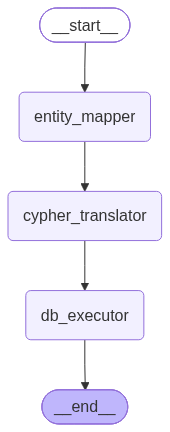

In [6]:
graph

In [7]:
# ==========================================
# 4. EXECUTE PIPELINE
# ==========================================
if __name__ == "__main__":
    sample_text = (
        "Satya Nadella is the CEO of Microsoft, which is headquartered in Redmond. "
        "Microsoft acquired GitHub in 2018."
    )
    
    initial_state: PipelineState = {
        "input_text": sample_text,
        "extracted_entities": [],
        "cypher_query": "",
        "db_status": ""
    }
    
    final_state = graph.invoke(initial_state)
    
    print("\n================ FINAL STATE ================")
    print(f"Status: {final_state['db_status']}")


--- [AGENT 1] Extracting Entities & Relationships ---
Extracted 3 relationships.

--- [AGENT 2] Translating Entities to Cypher Query ---
Generated Cypher Query:
```cypher
// Create / match the nodes
MERGE (p:Person {name: 'Satya Nadella'})
MERGE (m:Company {name: 'Microsoft'})
MERGE (r:City {name: 'Redmond'})
MERGE (g:Company {name: 'GitHub'})

// Create the relationships
MERGE (p)-[:CEO_OF]->(m)
MERGE (m)-[:HEADQUARTERED_IN]->(r)
MERGE (m)-[:ACQUIRED]->(g);
```

--- [AGENT 3] Executing Query on Database ---
SUCCESS: Graph updated successfully using generated query.

================ FINAL STATE ================
Status: SUCCESS: Graph updated successfully using generated query.
